# Matplotlib — Medium

## Rules
- Object-oriented Matplotlib only.
- Prefer explicit choices over defaults.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

## Exercise 1 — Two series with clear scales

### Task
Reproduce the figure above.

### Constraints
- Show two series on the same plot area with distinct visual styles.
- Use explicit axis limits and ticks on both axes.
- Include a legend placed intentionally.
- Add a grid without overwhelming the data.

In [2]:
x = np.linspace(0, 12, 300)
y_a = np.sin(x) + 0.15 * rng.normal(size=len(x))
y_b = 0.8 * np.sin(x + 0.6) + 0.15 * rng.normal(size=len(x))

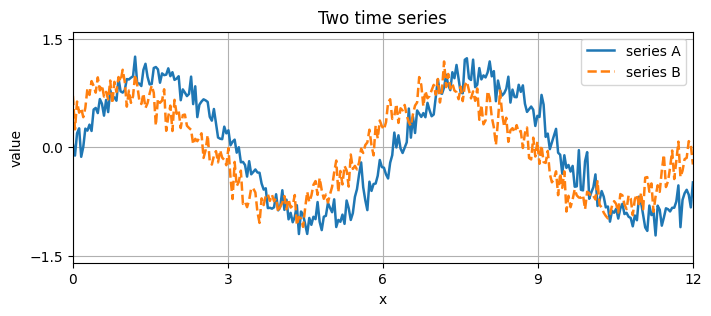

In [3]:
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(x, y_a, linewidth=1.8, label="series A")
ax.plot(x, y_b, linewidth=1.8, linestyle="--", label="series B")

ax.set_title("Two time series")
ax.set_xlabel("x")
ax.set_ylabel("value")

ax.set_xlim(0, 12)
ax.set_ylim(-1.6, 1.6)
ax.set_xticks([0, 3, 6, 9, 12])
ax.set_yticks([-1.5, 0.0, 1.5])

ax.grid(True)
ax.legend(loc="upper right")

plt.show()

## Exercise 2 — Scatter with a value-driven color scale

### Task
Reproduce the figure above.

### Constraints
- Visualize a relationship between two variables using points.
- Encode a third variable via color and include a color scale.
- Use transparency to reduce overplotting.
- Set explicit axis limits and ticks.

In [4]:
n = 220
xs = rng.normal(loc=0.0, scale=1.0, size=n)
ys = 0.7 * xs + rng.normal(loc=0.0, scale=0.8, size=n)
z = rng.normal(loc=50, scale=12, size=n)  # color variable

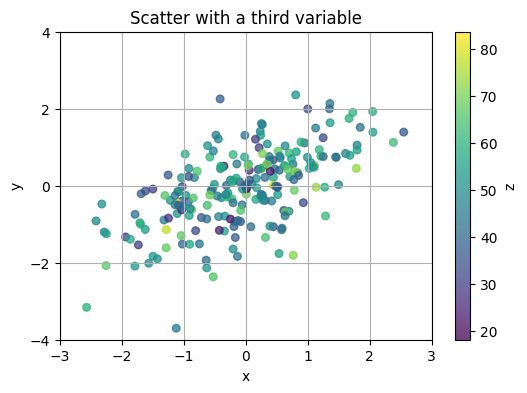

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

sc = ax.scatter(xs, ys, c=z, alpha=0.75, s=30, cmap="viridis")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("z")

ax.set_title("Scatter with a third variable")
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-4.0, 4.0)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-4, -2, 0, 2, 4])

ax.grid(True)

plt.show()

## Exercise 3 — Category bars with readable labels

### Task
Reproduce the figure above.

### Constraints
- Display category totals as bars.
- Leave visible headroom above the tallest bar.
- Rotate category labels for readability.
- Include a light horizontal grid and a legend.
- Display the numeric value above each bar.
- The labels must remain correctly positioned if the values change.


In [6]:
# 3) Categorical counts
cats = ["A", "B", "C", "D", "E", "F"]
counts = np.array([14, 8, 11, 5, 17, 9])


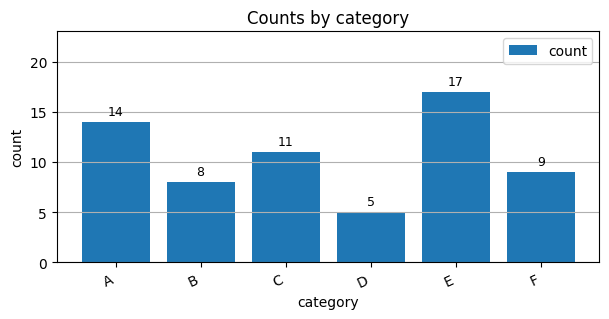

In [7]:
fig, ax = plt.subplots(figsize=(7, 3))

bars = ax.bar(cats, counts, label="count")

ax.set_title("Counts by category")
ax.set_xlabel("category")
ax.set_ylabel("count")

ax.set_ylim(0, int(counts.max()) + 6)
ax.set_yticks([0, 5, 10, 15, 20])

ax.set_xticks(range(len(cats)))
ax.set_xticklabels(cats, rotation=25, ha="right")

# Value labels on bars
for b in bars:
    h = b.get_height()
    ax.text(
        b.get_x() + b.get_width() / 2,
        h + 0.4,
        f"{int(h)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.grid(True, axis="y")
ax.legend(loc="upper right")

plt.show()


## Exercise 4 — Two distributions, comparable bins

### Task
Reproduce the figure above.

### Constraints
- Compare two distributions using the same bin edges.
- Use explicit bins so the comparison is stable and fair.
- Keep the vertical scale comparable across reruns.
- Include a legend and a light grid.

In [13]:
dist1 = rng.normal(loc=0.0, scale=1.0, size=600)
dist2 = rng.normal(loc=0.8, scale=1.2, size=600)

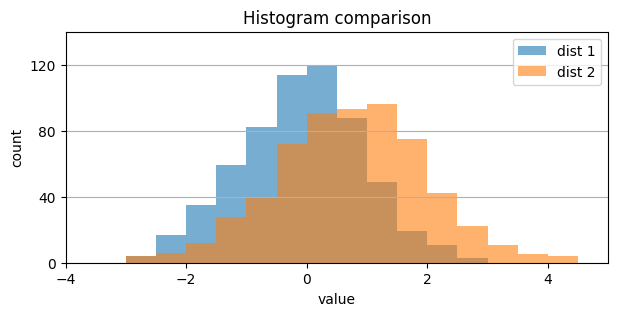

In [14]:
fig, ax = plt.subplots(figsize=(7, 3))

bins = np.linspace(-4, 5, 19)

ax.hist(dist1, bins=bins, alpha=0.6, label="dist 1")
ax.hist(dist2, bins=bins, alpha=0.6, label="dist 2")

ax.set_title("Histogram comparison")
ax.set_xlabel("value")
ax.set_ylabel("count")

ax.set_xlim(-4, 5)
ax.set_xticks([-4, -2, 0, 2, 4])
ax.set_ylim(0, 140)
ax.set_yticks([0, 40, 80, 120])

ax.grid(True, axis="y")
ax.legend(loc="upper right")

plt.show()

## Exercise 5 — Reference elements and highlighted range

### Task
Reproduce the figure above.

### Constraints
- Add a horizontal target marker.
- Highlight a horizontal range on the background for context.
- The context elements must not obscure the main data.
- Use explicit limits, ticks, and a legend.

In [10]:
x = np.linspace(0, 12, 300)
y_a = np.sin(x) + 0.15 * rng.normal(size=len(x))
y_b = 0.8 * np.sin(x + 0.6) + 0.15 * rng.normal(size=len(x))

event_start, event_end = 4.0, 6.5
threshold = 0.75


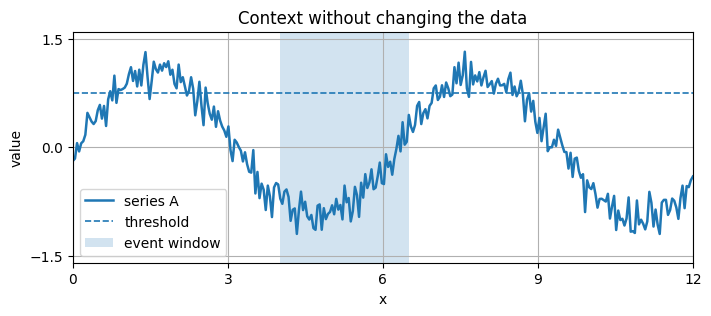

In [11]:
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(x, y_a, linewidth=1.8, label="series A")

ax.axhline(threshold, linestyle="--", linewidth=1.2, label="threshold")
ax.axvspan(event_start, event_end, alpha=0.2, label="event window")

ax.set_title("Context without changing the data")
ax.set_xlabel("x")
ax.set_ylabel("value")

ax.set_xlim(0, 12)
ax.set_ylim(-1.6, 1.6)
ax.set_xticks([0, 3, 6, 9, 12])
ax.set_yticks([-1.5, 0.0, 1.5])

ax.grid(True)
ax.legend(loc="lower left")

plt.show()

## Exercise 6 — Two-panel comparison with consistent scaling

### Task
Reproduce the figure above.

### Constraints
- Create two plot areas in one figure.
- The vertical scale must match so values are comparable across panels.
- Use explicit limits and ticks.
- Avoid duplicated labels where possible while keeping clarity.

In [12]:
x = np.linspace(0, 12, 300)
y_a = np.sin(x) + 0.15 * rng.normal(size=len(x))
y_b = 0.8 * np.sin(x + 0.6) + 0.15 * rng.normal(size=len(x))

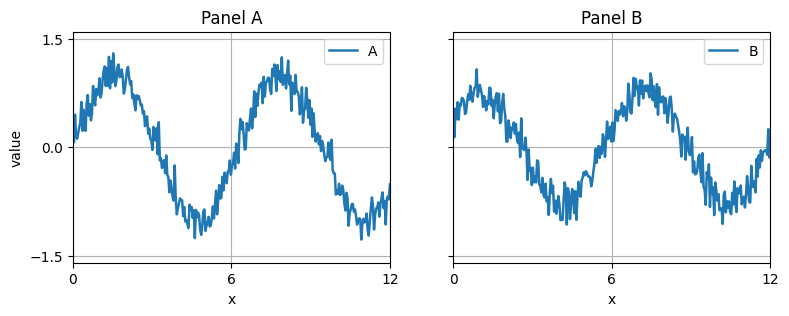

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(9, 3), sharey=True)

axs[0].plot(x, y_a, linewidth=1.8, label="A")
axs[1].plot(x, y_b, linewidth=1.8, label="B")

for ax in axs:
    ax.set_xlim(0, 12)
    ax.set_ylim(-1.6, 1.6)
    ax.set_xticks([0, 6, 12])
    ax.set_yticks([-1.5, 0.0, 1.5])
    ax.grid(True)
    ax.legend(loc="upper right")
    ax.set_xlabel("x")

axs[0].set_ylabel("value")
axs[0].set_title("Panel A")
axs[1].set_title("Panel B")

plt.show()

## Exercise 7 — Stacked bars with clear totals

### Task
Reproduce the figure above.

### Constraints
- Show two components per category as a stacked total.
- Keep the vertical scale explicit and readable.
- Use rotated tick labels for readability.
- Add a legend that explains the components.

In [14]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
sales = np.array([120, 90, 140, 110, 160, 130])
costs = np.array([70, 55, 85, 65, 95, 80])

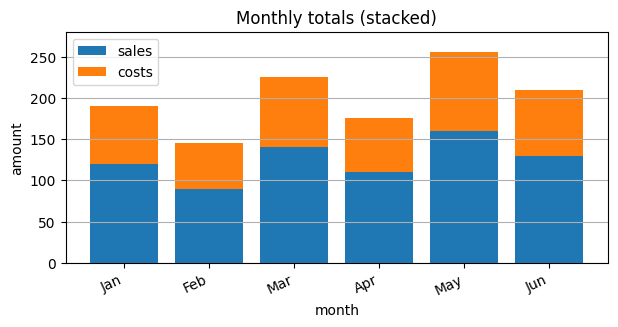

In [15]:
fig, ax = plt.subplots(figsize=(7, 3))

ax.bar(months, sales, label="sales")
ax.bar(months, costs, bottom=sales, label="costs")

ax.set_title("Monthly totals (stacked)")
ax.set_xlabel("month")
ax.set_ylabel("amount")

ax.set_ylim(0, 280)
ax.set_yticks([0, 50, 100, 150, 200, 250])

ax.set_xticks(range(len(months)))
ax.set_xticklabels(months, rotation=25, ha="right")

ax.grid(True, axis="y")
ax.legend(loc="upper left")

plt.show()

## Exercise 8 — A plot-area label that stays put

### Task
Reproduce the figure above.

### Constraints
- Add a short label that stays in the same corner of the plot area when rescaling.
- Keep explicit limits, ticks, and labels.
- The label must not overlap the legend or the data.

In [16]:
x = np.linspace(0, 12, 300)
y_a = np.sin(x) + 0.15 * rng.normal(size=len(x))

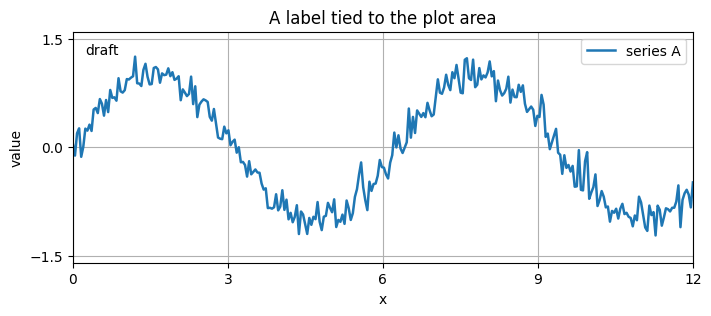

In [18]:
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(x, y_a, linewidth=1.8, label="series A")

ax.set_title("A label tied to the plot area")
ax.set_xlabel("x")
ax.set_ylabel("value")

ax.set_xlim(0, 12)
ax.set_ylim(-1.6, 1.6)
ax.set_xticks([0, 3, 6, 9, 12])
ax.set_yticks([-1.5, 0.0, 1.5])

ax.text(0.02, 0.95, "draft", transform=ax.transAxes, va="top", ha="left", fontsize=10)

ax.grid(True)
ax.legend(loc="upper right")

plt.show()